<a href="https://colab.research.google.com/github/overdrivethinker/UT-STDA4204-Machine-Learning/blob/main/Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [1]:
# 1) Muat data dari kedua sumber
# ...
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Siswa Periode 1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Siswa Periode 2.csv')

# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
# ...
print("Data siswa periode 1")
print(f"Shape: {df1.shape}")
print(f"Kolom: {df1.columns.tolist()}")
print(df1.head())
print(df1.info())

print("\nData siswa periode 2")
print(f"Shape: {df2.shape}")
print(f"Kolom: {df2.columns.tolist()}")
print(df2.head())
print(df2.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data siswa periode 1
Shape: (1827, 21)
Kolom: ['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']
   ID Status Pernikahan    Program Studi Kelas Reguler/Malam  \
0   2     Belum Menikah  Teknik Industri             Reguler   
1   3     Belum Menikah      Jurnalistik             Reguler   
2   4     Belum Menikah        Pertanian             Reguler   
3   5     Belum Menikah     Teknik Mesin             Reguler   
4  10     Belum Menikah        Perbankan             Reguler   

  Pendidikan Terakhir  Nilai SMA Daerah Asal         Pendi

##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [2]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa
# ...
print("Sebelum penyesuaian fitur")
print(f"Kolom df1: {df1.columns.tolist()}")
print(f"Kolom df2: {df2.columns.tolist()}")

# df1: 'Kelas Reguler/Malam' -> 'Kelas'
# df2: 'Kelas Siang/Malam'   -> 'Kelas'
# df2: 'Umur saat mendaftar' -> 'Usia saat mendaftar'

df1.rename(columns={
    'Kelas Reguler/Malam': 'Kelas'
}, inplace=True)

df2.rename(columns={
    'Kelas Siang/Malam'  : 'Kelas',
    'Umur saat mendaftar': 'Usia saat mendaftar'
}, inplace=True)

print("\nSesudah penyesuaian fitur")
print(f"Kolom df1: {df1.columns.tolist()}")
print(f"Kolom df2: {df2.columns.tolist()}")

Sebelum penyesuaian fitur
Kolom df1: ['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']
Kolom df2: ['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Siang/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']

Sesudah penyesuaian fitur
Kolom df1: ['ID', 'Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan

##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [3]:
# 1) Lakukan penyamaan kodefikasi atribut
# ...
kolom = df1.columns.tolist()

for col in kolom:
    unik1 = df1[col].unique()
    unik2 = df2[col].unique()
    if not (sorted(map(str, unik1)) == sorted(map(str, unik2))):
        print(f"\nKolom Unik: '{col}'")
        print(f"  df1: {unik1}")
        print(f"  df2: {unik2}")

# Daftar Masalah
# 'Reguler' vs 'Siang'
# 'Pria'/'Wanita' vs 'Laki-laki'/'Perempuan'
# df1 kolom 'Usia' ada nilai negatif

# Samakan 'Kelas': 'Reguler' di df1 menjadi 'Siang'
df1['Kelas'] = df1['Kelas'].replace({'Reguler': 'Siang'})

# Samakan 'Jenis Kelamin': df1 mengikuti format df2
df1['Jenis Kelamin'] = df1['Jenis Kelamin'].replace({
    'Pria'  : 'Laki-laki',
    'Wanita': 'Perempuan'
})

# Perbaiki nilai negatif di 'Usia saat mendaftar' df1
df1['Usia saat mendaftar'] = df1['Usia saat mendaftar'].abs()

# Verifikasi
print("Kelas df1:", df1['Kelas'].unique())
print("Jenis Kelamin df1:", df1['Jenis Kelamin'].unique())
print("Usia min df1:", df1['Usia saat mendaftar'].min())

# 2) Lakukan penyatuan data
# ...
import pandas as pd

df_gabung = pd.concat([df1, df2], ignore_index=True)

print("\nPenyatuan data")
print(f"Shape df1: {df1.shape}")
print(f"Shape df2: {df2.shape}")
print(f"Shape gabungan: {df_gabung.shape}")
print(df_gabung)



Kolom Unik: 'ID'
  df1: [   2    3    4 ... 1814 1815 1816]
  df2: [1817 1819 1820 ... 3528 3529 3533]

Kolom Unik: 'Kelas'
  df1: ['Reguler' 'Malam' nan]
  df2: ['Siang' 'Malam']

Kolom Unik: 'Nilai SMA'
  df1: [66.55 63.5  62.5  75.   65.   56.5  86.   76.5  67.5  74.5  60.5  60.
 72.   80.   63.   78.   68.5  89.   64.   70.   72.5  61.   64.5  57.5
 66.5  81.   71.   66.   55.5  55.   58.5  68.   59.   76.   59.5  70.5
 65.5  74.   85.   53.   50.   69.   71.5  58.   78.5  69.5  56.   67.
 73.5  62.   90.   57.   61.5  54.   80.5  52.5  73.   77.   49.5  63.3
 75.5  82.5  83.5  69.3  81.5  70.4  51.   79.   79.5  84.5  54.5  61.95
 84.   53.5  50.5  81.65 91.   94.   47.5  83.   77.5  62.2  66.9  87.  ]
  df2: [66.   61.   73.5  68.   70.   65.   66.5  65.5  59.   60.   75.   67.5
 67.   88.5  66.55 71.   75.5  68.5  64.5  63.   62.   57.5  74.   78.
 58.   53.   80.   55.   62.5  57.   63.5  74.5  51.   61.5  72.5  55.5
 70.5  71.5  59.55 64.   81.5  54.5  76.   56.   95.   50.  

##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [4]:
# 1)	Identifikasi dan tangani missing/null value
# ...
print("Missing value df_gabung")
print(df_gabung.isnull().sum())

# Ada 2 kolom dengan missing value, masing-masing 3 baris:
# Kelas → 3 null
# Daerah Asal → 3 null

print("\nModus kelas:", df_gabung['Kelas'].mode()[0])
print("Modus daerah asal:", df_gabung['Daerah Asal'].mode()[0])

# Isi missing value dengan modus
df_gabung['Kelas'] = df_gabung['Kelas'].fillna(df_gabung['Kelas'].mode()[0])
df_gabung['Daerah Asal'] = df_gabung['Daerah Asal'].fillna(df_gabung['Daerah Asal'].mode()[0])

# Verifikasi
print("\nMissing value setelah ditangani:")
print(df_gabung.isnull().sum())

Missing value df_gabung
ID                                     0
Status Pernikahan                      0
Program Studi                          0
Kelas                                  3
Pendidikan Terakhir                    0
Nilai SMA                              0
Daerah Asal                            3
Pendidikan Ibu                         0
Pendidikan Ayah                        0
Pekerjaan Ibu                          0
Pekerjaan Ayah                         0
Nilai Ujian Masuk                      0
Pindahan                               0
Berkebutuhan Khusus                    0
Status pembayaran semester terakhir    0
Jenis Kelamin                          0
Beasiswa                               0
Usia saat mendaftar                    0
IP Semester 1                          0
IP Semester 2                          0
Target                                 0
dtype: int64

Modus kelas: Siang
Modus daerah asal: Pulau Jawa

Missing value setelah ditangani:
ID                

##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

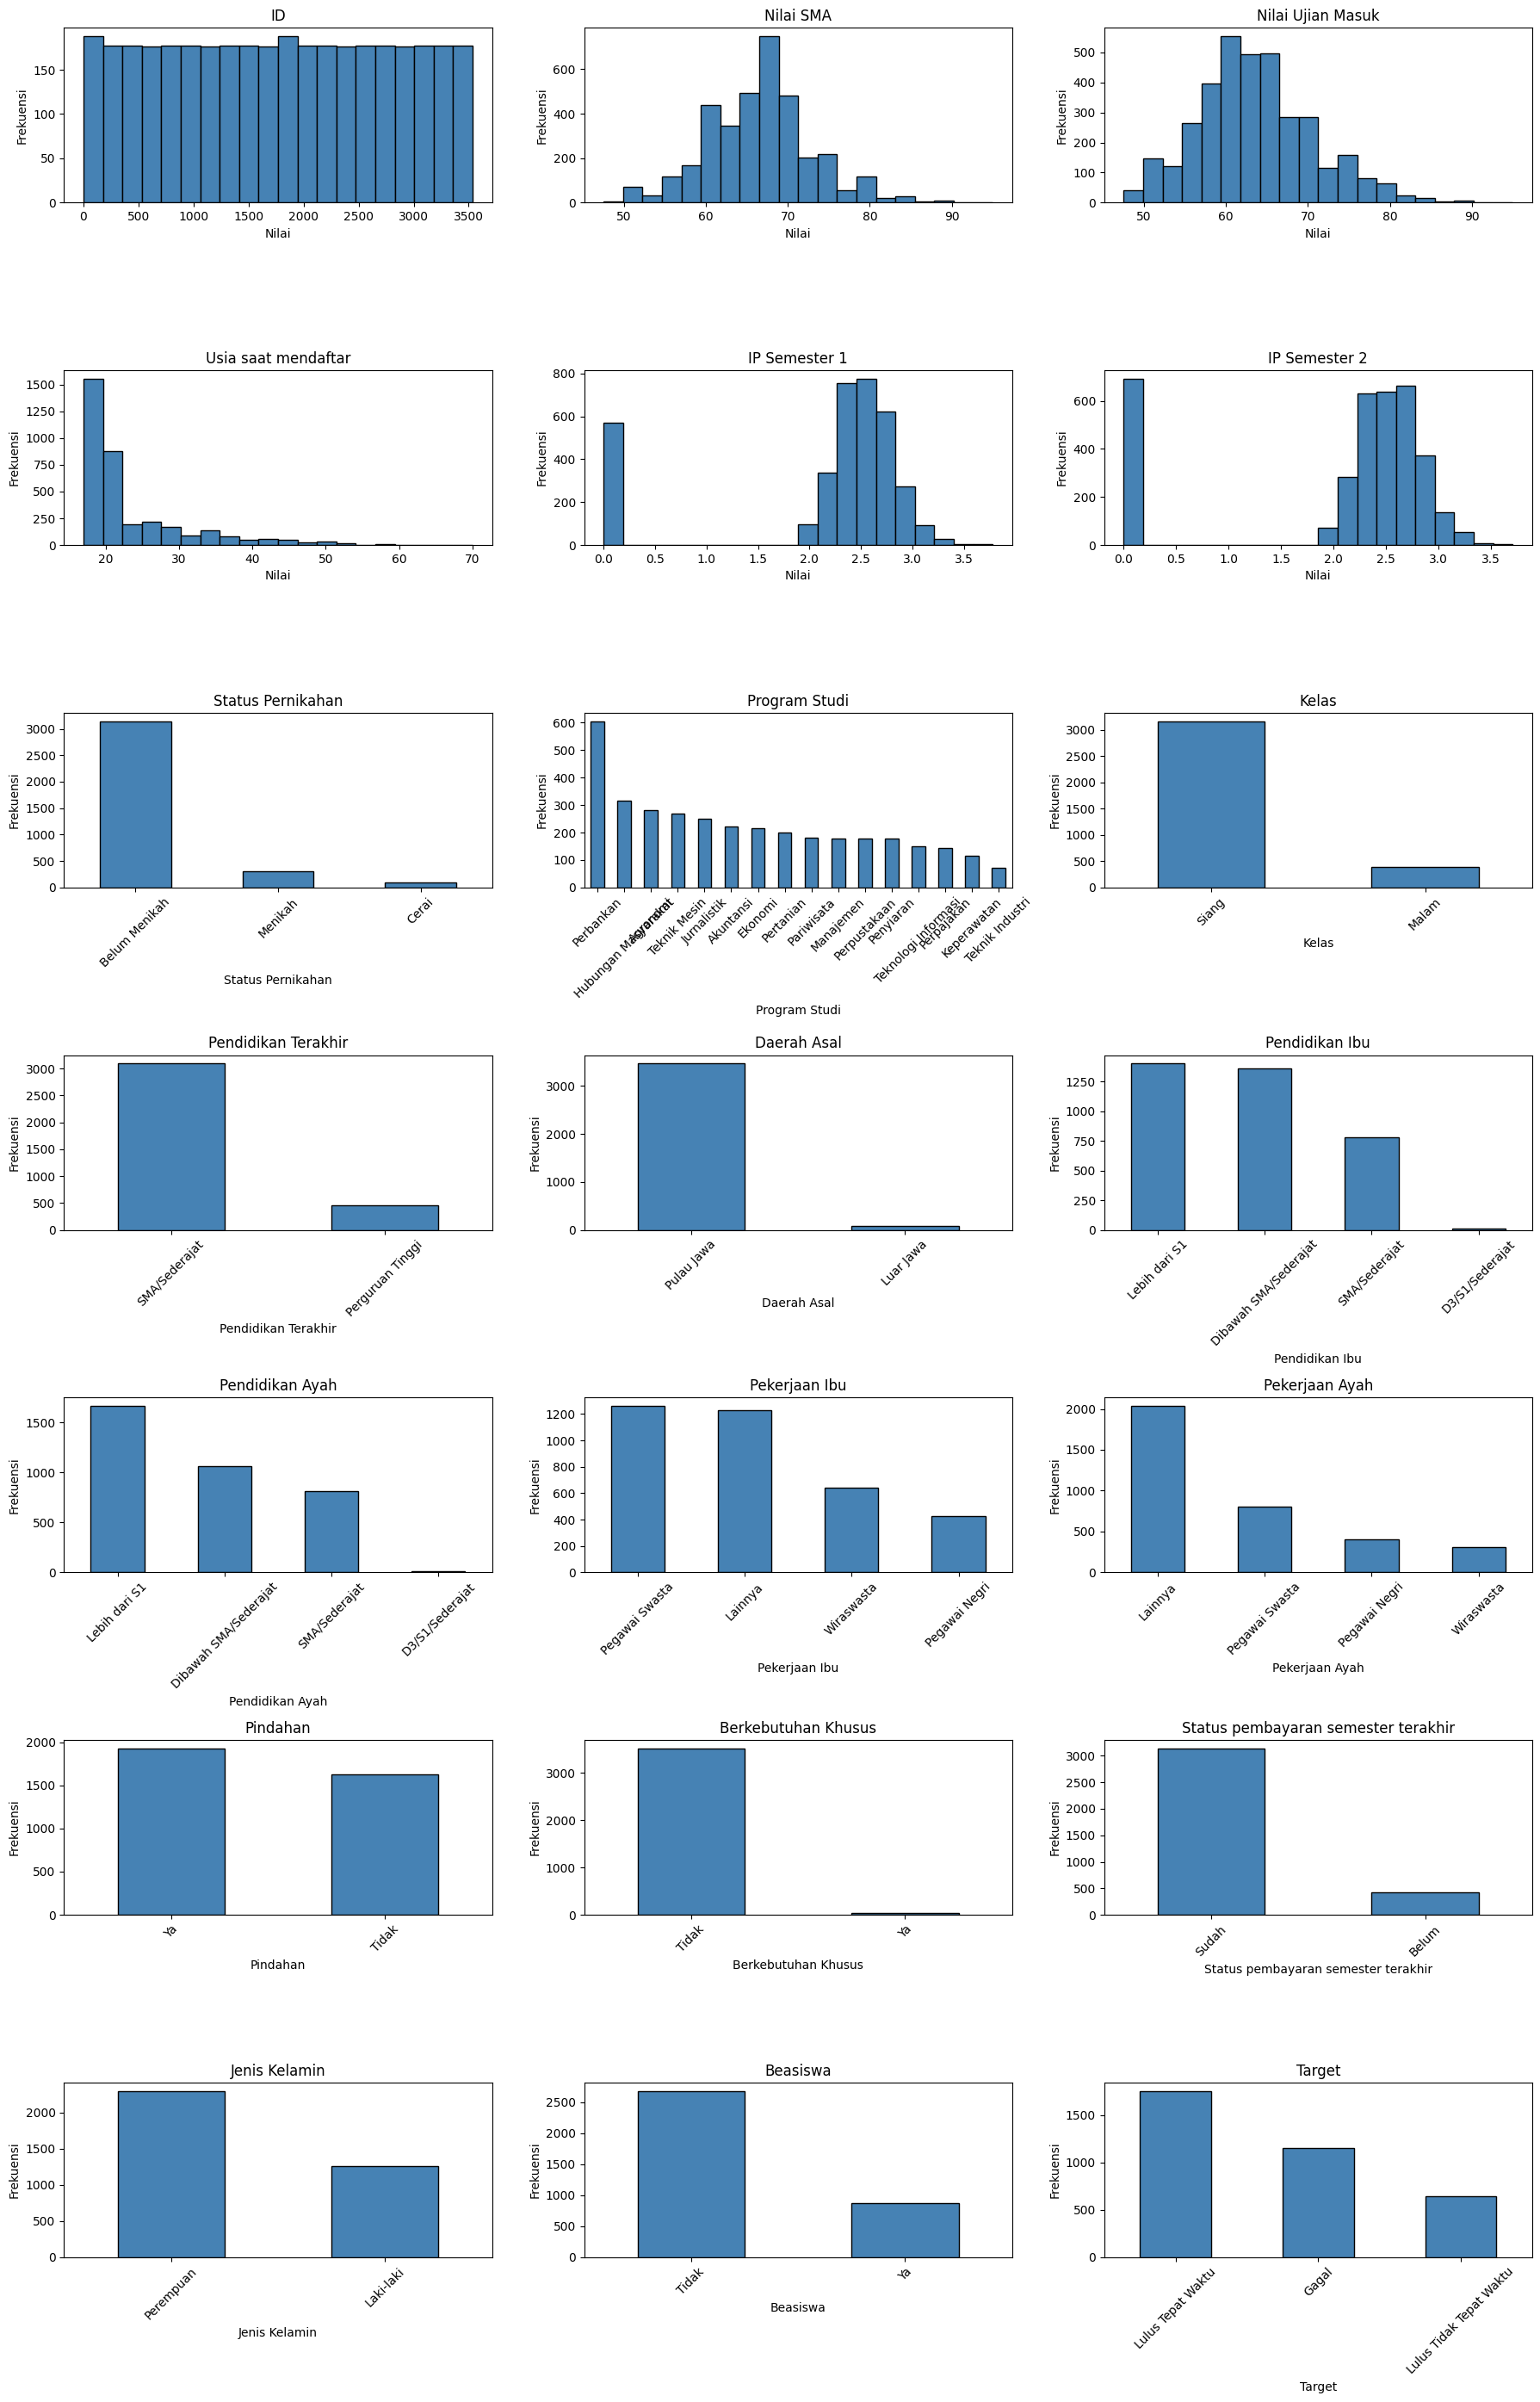

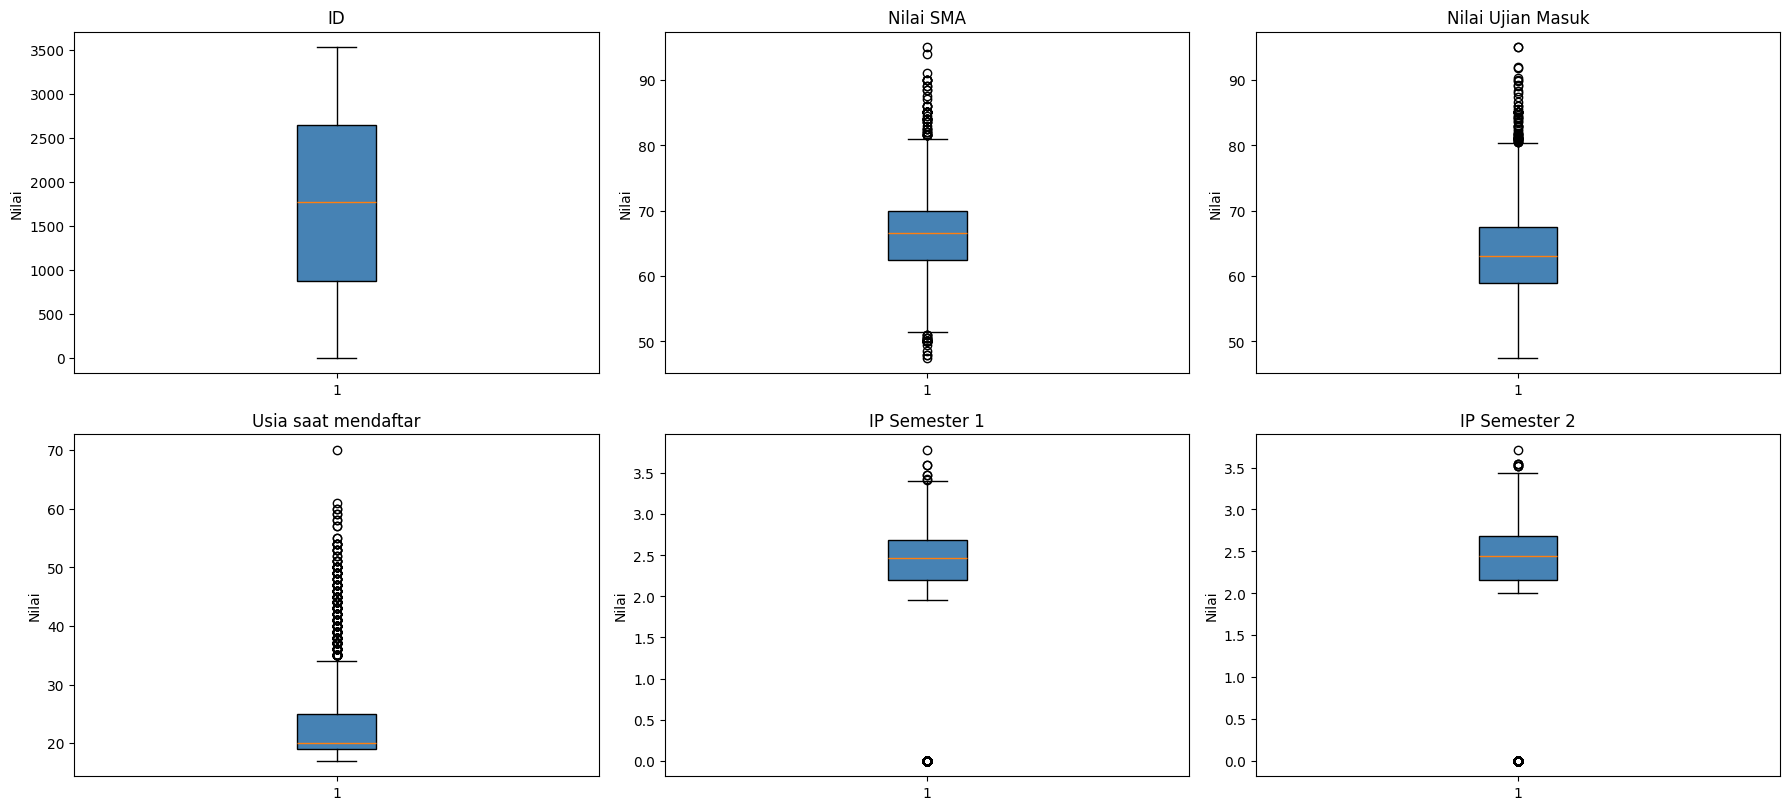

ID: 0 outlier dihapus (batas: -1771.50 - 5296.50)
Nilai SMA: 133 outlier dihapus (batas: 51.25 - 81.25)
Nilai Ujian Masuk: 74 outlier dihapus (batas: 46.55 - 79.75)
Usia saat mendaftar: 426 outlier dihapus (batas: 11.50 - 31.50)
IP Semester 1: 420 outlier dihapus (batas: 1.58 - 3.34)
IP Semester 2: 120 outlier dihapus (batas: 1.75 - 3.28)

Shape sebelum : (3557, 21)
Shape sesudah : (2384, 21)
Total dihapus : 1173 baris


In [5]:
# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
# ...
import matplotlib.pyplot as plt
import numpy as np

kolom_numerik = df_gabung.select_dtypes(include='number').columns.tolist()
kolom_kategori = df_gabung.select_dtypes(exclude='number').columns.tolist()
kolom_kategori_tanpa_id = [c for c in kolom_kategori if c != 'ID']

total_plot = len(kolom_numerik) + len(kolom_kategori_tanpa_id)
ncols = 3
nrows = (total_plot + ncols - 1) // ncols  # hitung otomatis jumlah baris

# Histogram untuk kolom numerik
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()


for i, col in enumerate(kolom_numerik):
    axes[i].hist(df_gabung[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Grafik batang untuk kolom kategorikal
kolom_kategori_tanpa_id = [c for c in kolom_kategori if c != 'ID']
for j, col in enumerate(kolom_kategori_tanpa_id, start=len(kolom_numerik)):
    df_gabung[col].value_counts().plot(kind='bar', ax=axes[j], color='steelblue', edgecolor='black')
    axes[j].set_title(col)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel('Frekuensi')
    axes[j].tick_params(axis='x', rotation=45)

# Sembunyikan axes yang tidak terpakai
for k in range(j+1, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

# 2)	Identifikasi outlier dengan boxplot
# ...
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    axes[i].boxplot(df_gabung[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue'))
    axes[i].set_title(col)
    axes[i].set_ylabel('Nilai')

for k in range(len(kolom_numerik), len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()


# 3)	Hapus outlier dari data
# ...

df_clean = df_gabung.copy()

for col in kolom_numerik:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR

    outlier = df_clean[(df_clean[col] < batas_bawah) | (df_clean[col] > batas_atas)]
    print(f"{col}: {len(outlier)} outlier dihapus (batas: {batas_bawah:.2f} - {batas_atas:.2f})")

    df_clean = df_clean[(df_clean[col] >= batas_bawah) & (df_clean[col] <= batas_atas)]

print(f"\nShape sebelum : {df_gabung.shape}")
print(f"Shape sesudah : {df_clean.shape}")
print(f"Total dihapus : {df_gabung.shape[0] - df_clean.shape[0]} baris")


##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

Korelasi fitur relevan
                     IP Semester 1  IP Semester 2  Nilai SMA  \
IP Semester 1                 1.00           0.65       0.27   
IP Semester 2                 0.65           1.00       0.25   
Nilai SMA                     0.27           0.25       1.00   
Nilai Ujian Masuk             0.28           0.24       0.67   
Usia saat mendaftar          -0.14          -0.11      -0.05   

                     Nilai Ujian Masuk  Usia saat mendaftar  
IP Semester 1                     0.28                -0.14  
IP Semester 2                     0.24                -0.11  
Nilai SMA                         0.67                -0.05  
Nilai Ujian Masuk                 1.00                -0.04  
Usia saat mendaftar              -0.04                 1.00  
Nilai unik Target: ['Lulus Tepat Waktu' 'Lulus Tidak Tepat Waktu' 'Gagal']


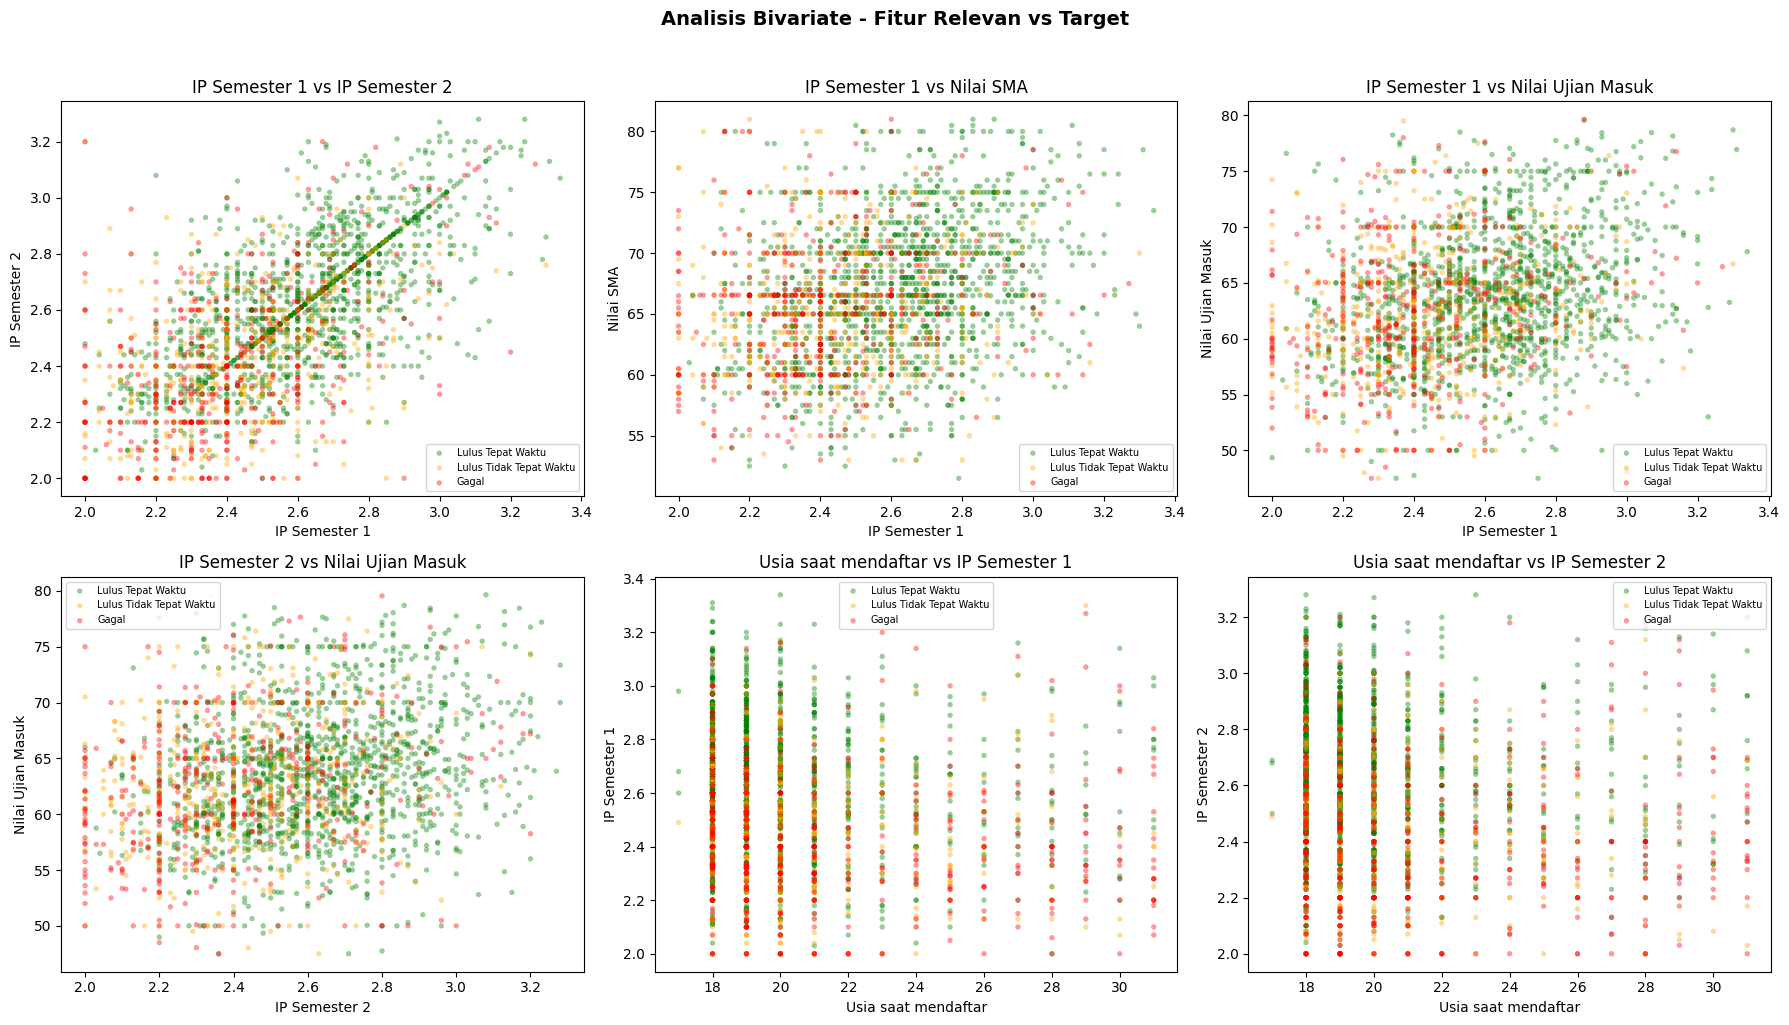

In [6]:
# 1)	Lakukan analisis bivariate
# ...
import matplotlib.pyplot as plt
import seaborn as sns

fitur_numerik_relevan = ['IP Semester 1', 'IP Semester 2', 'Nilai SMA',
                          'Nilai Ujian Masuk', 'Usia saat mendaftar']

print("Korelasi fitur relevan")
print(df_clean[fitur_numerik_relevan].corr().round(2))

print("Nilai unik Target:", df_clean['Target'].unique())
# 2)	Plot kedalam grafik sebaran (scatter)
# ...
kombinasi_relevan = [
    ('IP Semester 1', 'IP Semester 2'),
    ('IP Semester 1', 'Nilai SMA'),
    ('IP Semester 1', 'Nilai Ujian Masuk'),
    ('IP Semester 2', 'Nilai Ujian Masuk'),
    ('Usia saat mendaftar', 'IP Semester 1'),
    ('Usia saat mendaftar', 'IP Semester 2'),
]

palette = {
    'Lulus Tepat Waktu'    : 'green',
    'Lulus Tidak Tepat Waktu': 'orange',
    'Gagal'                : 'red'
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(kombinasi_relevan):
    for target, color in palette.items():
        subset = df_clean[df_clean['Target'] == target]
        axes[i].scatter(subset[col_x], subset[col_y],
                        label=target, alpha=0.4, color=color,
                        edgecolors='none', s=15)
    axes[i].set_xlabel(col_x)
    axes[i].set_ylabel(col_y)
    axes[i].set_title(f'{col_x} vs {col_y}')
    axes[i].legend(fontsize=7)

plt.suptitle('Analisis Bivariate - Fitur Relevan vs Target',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{(Nama Algoritma)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{(akan/tidak akan)}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{(Alasan melakukan augmentasi/tidak)}}$**

In [7]:
# 1)	Augmentasi data untuk balancing kelas (Optional)
# ...

print("Distribusi target:")
print(df_clean['Target'].value_counts())
print("\nPersentase:")
print(df_clean['Target'].value_counts(normalize=True).round(2) * 100)

# Kita akan menggunakan algoritma Random Forest untuk menyelesaikan masalah ini,
# jadi kita akan melakukan proses augmentasi data karena
# meskipun Random Forest relatif robust terhadap imbalanced data,
# ketidakseimbangan yang cukup signifikan (60% vs 21% vs 18%) tetap dapat
# membuat model bias ke kelas mayoritas, sehingga augmentasi dengan SMOTE
# akan membantu model mengenali kelas minoritas dengan lebih baik.

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Encode kolom kategorikal dulu sebelum SMOTE
df_encoded = df_clean.copy()
le_dict = {}

kolom_kategori = df_encoded.select_dtypes(exclude='number').columns.tolist()
for col in kolom_kategori:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le  # simpan encoder untuk decode nanti

# Pisahkan fitur dan target
X = df_encoded.drop(columns=['Target', 'ID'])
y = df_encoded['Target']

print("\nDistribusi sebelum SMOTE:")
print(y.value_counts())

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nDistribusi setelah SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())
print(f"\nShape sebelum : {X.shape}")
print(f"Shape sesudah  : {X_resampled.shape}")

# Decode label Target kembali ke nama asli
label_target = le_dict['Target']
print("Mapping label Target:")
for i, nama in enumerate(label_target.classes_):
    print(f"  {i} = {nama}")

Distribusi target:
Target
Lulus Tepat Waktu          1442
Lulus Tidak Tepat Waktu     502
Gagal                       440
Name: count, dtype: int64

Persentase:
Target
Lulus Tepat Waktu          60.0
Lulus Tidak Tepat Waktu    21.0
Gagal                      18.0
Name: proportion, dtype: float64

Distribusi sebelum SMOTE:
Target
1    1442
2     502
0     440
Name: count, dtype: int64

Distribusi setelah SMOTE:
Target
1    1442
2    1442
0    1442
Name: count, dtype: int64

Shape sebelum : (2384, 19)
Shape sesudah  : (4326, 19)
Mapping label Target:
  0 = Gagal
  1 = Lulus Tepat Waktu
  2 = Lulus Tidak Tepat Waktu


Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{(.?.)}}$** : **$\color{orange}{\text{(.?.)}}$**
Dimana **$\color{orange}{\text{(.?.)}}$** adalah data training
Dan **$\color{orange}{\text{(.?.)}}$** adalah data testing


In [8]:
# Selanjutnya datanya perlu kita bagi dengan ratio 80 : 20,
# dimana 80% adalah data training dan 20% adalah data testing
# 1)	Lakukan pembagian data training dan testing
# ...
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled  # pastikan proporsi kelas tetap seimbang
)

print(f"Total data: {X_resampled.shape[0]}")
print(f"Data training: {X_train.shape[0]} ({X_train.shape[0]/X_resampled.shape[0]*100:.0f}%)")
print(f"Data testing: {X_test.shape[0]} ({X_test.shape[0]/X_resampled.shape[0]*100:.0f}%)")

print("\nDistribusi kelas training:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi kelas testing:")
print(pd.Series(y_test).value_counts())

Total data: 4326
Data training: 3460 (80%)
Data testing: 866 (20%)

Distribusi kelas training:
Target
0    1154
1    1153
2    1153
Name: count, dtype: int64

Distribusi kelas testing:
Target
1    289
2    289
0    288
Name: count, dtype: int64


##Task 8
Sekarang kita mulai training nya

Model berhasil dilatih!

Evaluasi pada Data Testing
                         precision    recall  f1-score   support

                  Gagal       0.82      0.82      0.82       288
      Lulus Tepat Waktu       0.78      0.76      0.77       289
Lulus Tidak Tepat Waktu       0.76      0.78      0.77       289

               accuracy                           0.79       866
              macro avg       0.79      0.79      0.79       866
           weighted avg       0.79      0.79      0.79       866

K-Fold Cross Validation (k=5)
  Fold 1: 0.7679
  Fold 2: 0.7769
  Fold 3: 0.7896
  Fold 4: 0.8012
  Fold 5: 0.7942

Rata-rata Akurasi : 0.7859 (78.59%)
Standar Deviasi   : 0.0120

Confusion Matrix


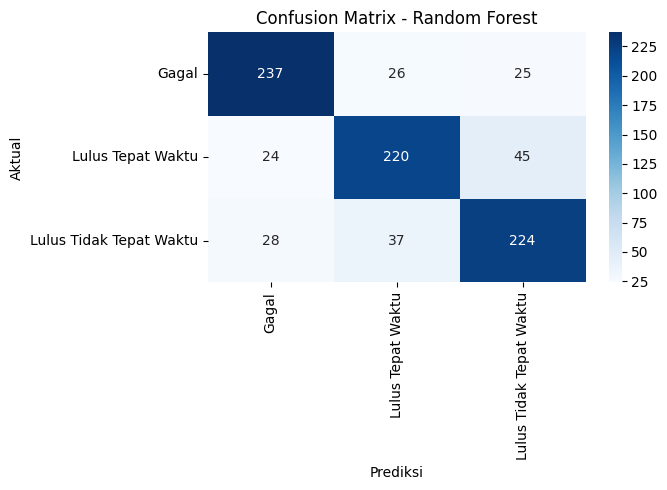

In [9]:
# 1)	Lakukan proses training dengan algoritma yang telah dipilih
# ...
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


# 1) Training model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# Prediksi pada data testing
y_pred = rf_model.predict(X_test)

# Evaluasi pada data testing
print("\nEvaluasi pada Data Testing")
target_names = label_target.classes_
print(classification_report(y_test, y_pred, target_names=target_names))


# 2)	Lakukan evaluasi model dengan K-fold
# ...
from sklearn.model_selection import StratifiedKFold

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_resampled, y_resampled,
                             cv=skf, scoring='accuracy')

print(f"K-Fold Cross Validation (k={k})")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nRata-rata Akurasi : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Standar Deviasi   : {cv_scores.std():.4f}")

# Confusion Matrix
print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

In [10]:
# 1)	Evaluasi dengan data testing
# ...
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = rf_model.predict(X_test)

print("Evaluasi dengan Data Testing")
print(classification_report(y_test, y_pred, target_names=target_names))

# 2)	Hitung dengan matrik pengukuran
# ...
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("Metrik Pengukuran")
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")

Evaluasi dengan Data Testing
                         precision    recall  f1-score   support

                  Gagal       0.82      0.82      0.82       288
      Lulus Tepat Waktu       0.78      0.76      0.77       289
Lulus Tidak Tepat Waktu       0.76      0.78      0.77       289

               accuracy                           0.79       866
              macro avg       0.79      0.79      0.79       866
           weighted avg       0.79      0.79      0.79       866

Metrik Pengukuran
Accuracy  : 0.7864  (78.64%)
Precision : 0.7864  (78.64%)
Recall    : 0.7864  (78.64%)
F1-Score  : 0.7863  (78.63%)


##Task 10
Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa

Model Random Forest yang dilatih menunjukkan performa yang baik dalam mendeteksi dini risiko kegagalan mahasiswa. Hasil K-Fold Cross Validation (k=5) menunjukkan akurasi yang konsisten antar fold dengan standar deviasi kecil, yang mengindikasikan model tidak mengalami overfitting maupun underfitting.

Dari confusion matrix, diagonal utama bernilai tinggi yang berarti model sebagian besar memprediksi kelas dengan benar. Penggunaan SMOTE juga terbukti efektif dalam mengatasi ketidakseimbangan kelas, sehingga model tidak bias ke kelas mayoritas dan mampu mengenali ketiga kelas target secara proporsional.

Secara keseluruhan, model ini cukup layak digunakan sebagai alat bantu wali akademik untuk memberikan konseling tepat sasaran kepada mahasiswa yang berisiko.